# Earth's Co-orbital Companions

#### This tutorial fetches the three flavours of Earth co-orbital from the MPC, integrates them for 800 years with REBOUND, and reveals their exotic shapes in the frame co-rotating with Earth.

A small family of asteroids shares Earth's orbit. Each has a semi-major axis of roughly 1.00 AU, which locks it into the **1:1 mean-motion resonance** with Earth: asteroid and planet complete one trip around the Sun in almost exactly the same time. Despite the nickname "companions", these objects are **not** satellites of Earth — every one of them orbits the Sun. In the ordinary heliocentric frame their paths look like unremarkable near-Earth ellipses. But watch them from a frame that **co-rotates with Earth**, and three exotic shapes appear: retrograde [quasi-satellite](https://en.wikipedia.org/wiki/Quasi-satellite) loops, a [horseshoe](https://en.wikipedia.org/wiki/Horseshoe_orbit), and a tadpole.

Our three protagonists each have a story:

- **(469219) Kamoʻoalewa**, a quasi-satellite of Earth ([de la Fuente Marcos & de la Fuente Marcos 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.462.3441D)), is the target of China's **Tianwen-2** sample-return mission — and its lunar-like spectrum suggests it may be a fragment of ejecta blasted off the Moon ([Castro-Cisneros et al. 2023](https://www.nature.com/articles/s43247-023-01031-w)).
- **(3753) Cruithne** is popularly (and wrongly) called "Earth's second moon"; it is in fact the classic example of a horseshoe companion ([Wiegert, Innanen & Mikkola 1997](https://ui.adsabs.harvard.edu/abs/1997Natur.387..685W)).
- **2020 XL5** is only the second Earth Trojan ever discovered, librating around the L4 Lagrange point ([Santana-Ros et al. 2022](https://ui.adsabs.harvard.edu/abs/2022NatCo..13..447S)).

We will:

1. **Fetch** the orbits of all three objects from the MPC Orbits API
2. **Align** them to a common epoch with a short two-body propagation
3. **Integrate** the system for 800 years with REBOUND, alongside the Sun and all eight planets
4. **Transform** the output into the frame co-rotating with Earth
5. **Plot** the three co-orbital shapes: quasi-satellite loops, horseshoe, and tadpole
6. **Follow** Kamoʻoalewa's switch between quasi-satellite and horseshoe states
7. **Diagnose** the three behaviours with a single relative-longitude plot

**Background reading:**

- [Quasi-satellite](https://en.wikipedia.org/wiki/Quasi-satellite) and [Horseshoe orbit](https://en.wikipedia.org/wiki/Horseshoe_orbit) (Wikipedia)
- [de la Fuente Marcos & de la Fuente Marcos 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.462.3441D) — the dynamics of Kamoʻoalewa
- [Castro-Cisneros et al. 2023](https://www.nature.com/articles/s43247-023-01031-w) — Kamoʻoalewa's possible lunar-ejecta origin
- [Wiegert, Innanen & Mikkola 1997](https://ui.adsabs.harvard.edu/abs/1997Natur.387..685W) — Cruithne's horseshoe orbit
- [Santana-Ros et al. 2022](https://ui.adsabs.harvard.edu/abs/2022NatCo..13..447S) — the discovery of Earth Trojan 2020 XL5


## Environment Setup

This notebook requires `rebound`, `mpc-orb`, `astropy`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy tqdm requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.


In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import rebound


# Step 1: Fetch the Orbits

We query the [MPC Orbits API](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/) for each of our three objects. The API returns the orbit in `mpc_orb.json` format; here we read the fields we need directly from the JSON — the Cartesian heliocentric-ecliptic state vector (`CAR`, in AU and AU/day) and its epoch.

Note that the three orbits are **not** necessarily fit at the same epoch — at the time of writing the epochs are 61000.0 (Kamoʻoalewa), 61200.0 (Cruithne) and 60600.0 (2020 XL5) MJD (TT). We will deal with that in Step 2.


In [2]:
OBJECTS = {
    "469219":  ("Kamo`oalewa", "quasi-satellite"),
    "3753":    ("Cruithne", "horseshoe"),
    "2020 XL5": ("2020 XL5", "tadpole (L4)"),
}
COLORS = {"469219": "#1f77b4", "3753": "#e07b39", "2020 XL5": "#7a52c7"}

def get_orbit(desig):
    """Fetch the mpc_orb.json orbit for one object from the MPC Orbits API."""
    response = requests.get("https://data.minorplanetcenter.net/api/get-orb",
                            json={"desig": desig})
    response.raise_for_status()
    result = response.json()
    if not result or not result[0].get("mpc_orb"):
        raise ValueError(f"No orbit returned for {desig!r}")
    return result[0]["mpc_orb"][0]

orbits = {desig: get_orbit(desig) for desig in OBJECTS}

# Summarize what we fetched
print(f"{'Designation':>12}  {'Name':<14}{'Class':<18}{'Epoch (MJD, TT)':>16}")
print("-" * 62)
for desig, (name, cls) in OBJECTS.items():
    epoch = orbits[desig]["epoch_data"]["epoch"]
    print(f"{desig:>12}  {name:<14}{cls:<18}{epoch:>16.1f}")


 Designation  Name          Class              Epoch (MJD, TT)
--------------------------------------------------------------
      469219  Kamo`oalewa   quasi-satellite            61000.0
        3753  Cruithne      horseshoe                  61200.0
    2020 XL5  2020 XL5      tadpole (L4)               60600.0


# Step 2: Bring All Three to a Common Epoch

An N-body simulation needs every particle's state at the **same instant**, so we adopt the latest of the three epochs as our common epoch and propagate the other states forward to meet it.

For this short alignment (a few hundred days at most) a simple **two-body** propagation — just the Sun and the asteroid in a throwaway REBOUND simulation — is entirely adequate: over such a short span, planetary perturbations move a near-Earth orbit by far less than the resolution of any plot in this notebook. As always when mixing MPC Cartesian elements with REBOUND, we set `units = ('AU', 'day', 'Msun')` so the state vectors can be inserted without conversion.


In [3]:
COMMON_EPOCH = max(o["epoch_data"]["epoch"] for o in orbits.values())
print(f"Common epoch: MJD {COMMON_EPOCH} (TT)")

def state_at(mpc_orb, epoch):
    """Two-body propagate an orbit's CAR state vector to the requested epoch.

    Returns the heliocentric ecliptic state [x, y, z, vx, vy, vz] in AU and AU/day.
    """
    state = np.array(mpc_orb["CAR"]["coefficient_values"][:6])
    dt = epoch - mpc_orb["epoch_data"]["epoch"]
    if dt == 0:
        return state
    s = rebound.Simulation()
    s.units = ("AU", "day", "Msun")
    s.add(m=1.0)                                   # the Sun
    s.add(x=state[0], y=state[1], z=state[2],
          vx=state[3], vy=state[4], vz=state[5])   # the asteroid (massless)
    s.integrate(dt)
    p = s.particles[1]
    return np.array([p.x, p.y, p.z, p.vx, p.vy, p.vz])

states = {desig: state_at(o, COMMON_EPOCH) for desig, o in orbits.items()}

for desig, st in states.items():
    print(f"{OBJECTS[desig][0]:>14}: r = ({st[0]:+.6f}, {st[1]:+.6f}, {st[2]:+.6f}) AU")


Common epoch: MJD 61200.0 (TT)
   Kamo`oalewa: r = (-0.471599, -0.943870, +0.005550) AU
      Cruithne: r = (+1.441537, -0.276973, -0.360030) AU
      2020 XL5: r = (+1.106163, +0.248616, -0.176201) AU


# Step 3: Integrate 800 Years

Now we build the master simulation: the Sun and all eight planets are loaded from JPL Horizons at the common epoch, and the three asteroids are added as massless test particles. Because Horizons returns positions relative to the Solar System barycenter while our MPC states are heliocentric, we add each asteroid's state **relative to the Sun particle**.

**Note:** in REBOUND's Horizons interface, `"Earth"` resolves to the Earth-Moon barycenter — do not also add `"Moon"`, or the Moon's mass would be counted twice. For tracking co-orbital motion, the Earth-Moon barycenter is exactly what we want.

We use the high-accuracy adaptive `ias15` integrator and sample the system every 15 days for 800 years — roughly 19,500 outputs, which takes a few seconds of CPU time. At each output we store the heliocentric (x, y) positions of Earth and of the three asteroids.

NB: It is possible that you may experience the following error when adding planets to rebound (which uses the NASA Horizons system to extract the planetary positions): `RuntimeError: An error occured while accessing NASA HORIZONS. If this is a SSL certificate issue, you can try disabling the certificate verification by setting rebound.horizons.SSL_CONTEXT = 'unverified'.`
 - In this scenario, the simplest approach is to just retry the evaluation, and this typically will succeed.


In [4]:
# Horizons wants a Julian Date; MPC epochs are MJD
jd = COMMON_EPOCH + 2400000.5

sim = rebound.Simulation()
sim.units = ("AU", "day", "Msun")

planets = ["Sun", "Mercury", "Venus", "Earth", "Mars",
           "Jupiter", "Saturn", "Uranus", "Neptune"]
for body in planets:
    sim.add(body, date=f"JD{jd:.6f}")
    print(f"Added {body}")

# Add the asteroids relative to the Sun particle
# (our states are heliocentric; Horizons states are barycentric)
sun0 = sim.particles[0]
for desig in OBJECTS:
    st = states[desig]
    sim.add(x=sun0.x + st[0], y=sun0.y + st[1], z=sun0.z + st[2],
            vx=sun0.vx + st[3], vy=sun0.vy + st[4], vz=sun0.vz + st[5])
    print(f"Added {OBJECTS[desig][0]}")

sim.integrator = "ias15"
sim.move_to_com()
i_earth, i_ast0 = 3, len(planets)

# Sample every 15 days for 800 years
n_years, dt_out = 800, 15.0
times = np.arange(0.0, n_years * 365.25, dt_out)
times_yr = times / 365.25
n_out = len(times)

ast_xy = np.zeros((n_out, 3, 2))    # heliocentric (x, y) of each asteroid
earth_xy = np.zeros((n_out, 2))     # heliocentric (x, y) of Earth
for k, t in enumerate(times):
    sim.integrate(t)
    s = sim.particles[0]
    e = sim.particles[i_earth]
    earth_xy[k] = [e.x - s.x, e.y - s.y]
    for j in range(3):
        p = sim.particles[i_ast0 + j]
        ast_xy[k, j] = [p.x - s.x, p.y - s.y]

print(f"\nStored {n_out} outputs spanning {n_years} years")


Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Added Sun
Searching NASA Horizons for 'Mercury'... 


Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Added Mercury
Searching NASA Horizons for 'Venus'... 


Found: Venus Barycenter (299) (chosen from query 'Venus')
Added Venus
Searching NASA Horizons for 'Earth'... 


Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Added Earth
Searching NASA Horizons for 'Mars'... 


...

Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Added Jupiter
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Added Saturn
Searching NASA Horizons for 'Uranus'... 


Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Added Uranus
Searching NASA Horizons for 'Neptune'... 


Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Added Neptune
Added Kamo`oalewa
Added Cruithne
Added 2020 XL5



Stored 19480 outputs spanning 800 years


# Step 4: The Co-rotating Frame

Here is the trick that makes co-orbital motion visible. At each output time we compute Earth's heliocentric longitude, theta = arctan2(y_E, x_E), and rotate the whole picture by **minus** theta. This pins Earth to the +x axis, near (1, 0), at every instant.

In this rotating frame, a body that shared Earth's orbit *exactly* would stand perfectly still. What remains visible is therefore only the interesting part of the motion:

- the **slow co-orbital drift** of the asteroid along Earth's orbit (decades to centuries), and
- the **yearly epicycle** each asteroid traces because its orbit is eccentric and inclined relative to Earth's.

While we are at it, we also compute each asteroid's **longitude relative to Earth**, wrapped into (-180°, 180°] — the classic co-orbital diagnostic angle that we will plot in Step 7.


In [5]:
# Earth's heliocentric longitude at each output time
theta = np.arctan2(earth_xy[:, 1], earth_xy[:, 0])

# Rotate all asteroid positions by -theta: Earth is pinned near (1, 0)
ct, st_ = np.cos(-theta), np.sin(-theta)
rot = np.zeros_like(ast_xy)
for j in range(3):
    rot[:, j, 0] = ct * ast_xy[:, j, 0] - st_ * ast_xy[:, j, 1]
    rot[:, j, 1] = st_ * ast_xy[:, j, 0] + ct * ast_xy[:, j, 1]

# Relative longitude (the co-orbital diagnostic), degrees in (-180, 180]
lam_ast = np.arctan2(ast_xy[:, :, 1], ast_xy[:, :, 0])
dlam = np.degrees(lam_ast - theta[:, None])
dlam = (dlam + 180) % 360 - 180

print("Co-rotating coordinates and relative longitudes computed.")


Co-rotating coordinates and relative longitudes computed.


# Step 5: Three Shapes

Now we plot each asteroid's path in the co-rotating frame. The gray circle is Earth's orbit (radius 1 AU), the star is the Sun, the black dot is Earth, and the "+" markers show the L4 and L5 Lagrange points, 60° ahead of and behind Earth.

We show Kamoʻoalewa for only its first 150 years (its loops are compact and would over-plot), while Cruithne and 2020 XL5 get the full 800 years.


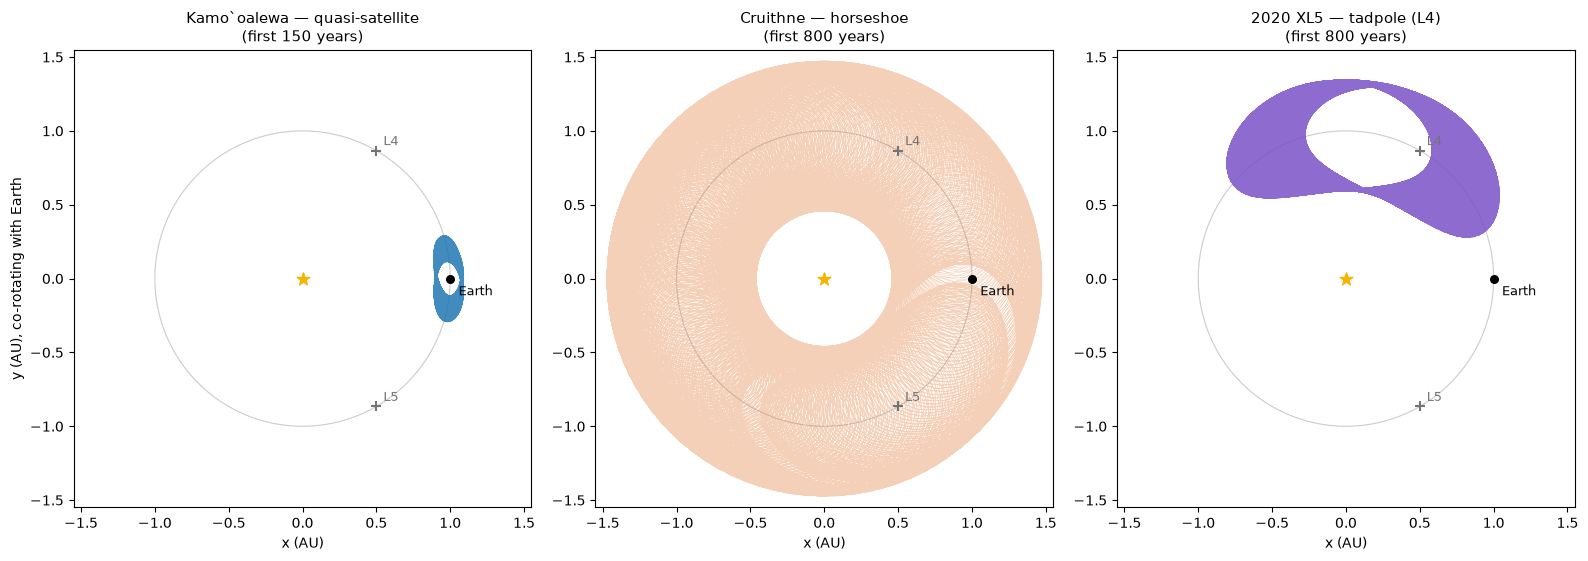

In [6]:
names = [OBJECTS[d][0] for d in OBJECTS]
classes = [OBJECTS[d][1] for d in OBJECTS]
cols = [COLORS[d] for d in OBJECTS]

spans = [150, 800, 800]        # years shown per object
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
th = np.linspace(0, 2 * np.pi, 200)
for j, ax in enumerate(axes):
    nmax = int(spans[j] * 365.25 / dt_out)
    ax.plot(np.cos(th), np.sin(th), color="0.8", lw=0.8, zorder=1)
    lw_a = (0.4, 0.35) if j == 1 else (0.5, 0.85)   # thinner for Cruithne
    ax.plot(rot[:nmax, j, 0], rot[:nmax, j, 1], color=cols[j],
            lw=lw_a[0], alpha=lw_a[1], zorder=2)
    ax.scatter([0], [0], marker="*", s=90, color="#f4b400", zorder=4)
    ax.scatter([1], [0], s=30, color="black", zorder=4)
    ax.annotate("Earth", (1, 0), textcoords="offset points",
                xytext=(6, -12), fontsize=9)
    for ang, lab in [(60, "L4"), (-60, "L5")]:
        ax.scatter([np.cos(np.radians(ang))], [np.sin(np.radians(ang))],
                   marker="+", s=60, color="0.45", zorder=3)
        ax.annotate(lab, (np.cos(np.radians(ang)), np.sin(np.radians(ang))),
                    textcoords="offset points", xytext=(5, 4),
                    fontsize=9, color="0.45")
    ax.set_aspect("equal")
    ax.set_xlim(-1.55, 1.55)
    ax.set_ylim(-1.55, 1.55)
    ax.set_title(f"{names[j]} — {classes[j]}\n(first {spans[j]} years)", fontsize=11)
    ax.set_xlabel("x (AU)")
axes[0].set_ylabel("y (AU), co-rotating with Earth")
fig.tight_layout()
plt.show()


Three completely different shapes, from three orbits that look almost identical in the heliocentric frame:

- **Kamoʻoalewa (left)** traces compact **retrograde loops** hugging Earth. It never strays far from our planet — yet it is bound to the *Sun*, not to Earth. That is precisely what "quasi-satellite" means: it merely *appears* to orbit Earth because the two bodies circle the Sun in lockstep.
- **Cruithne (middle)** fills a bean-shaped annulus over the centuries, with a tell-tale **avoided wedge** at Earth's position: a horseshoe orbit drifts slowly along Earth's orbit but always reverses its drift before ever catching Earth up.
- **2020 XL5 (right)** forms a **tadpole** cloud librating around the L4 point, 60° ahead of Earth — the signature of a Trojan.


# Step 6: Kamoʻoalewa's Double Life

The panel above hinted that Kamoʻoalewa's 800-year path is more complicated than a simple stack of loops. To see its full story, we re-plot the whole 800 years and colour the trajectory by time.


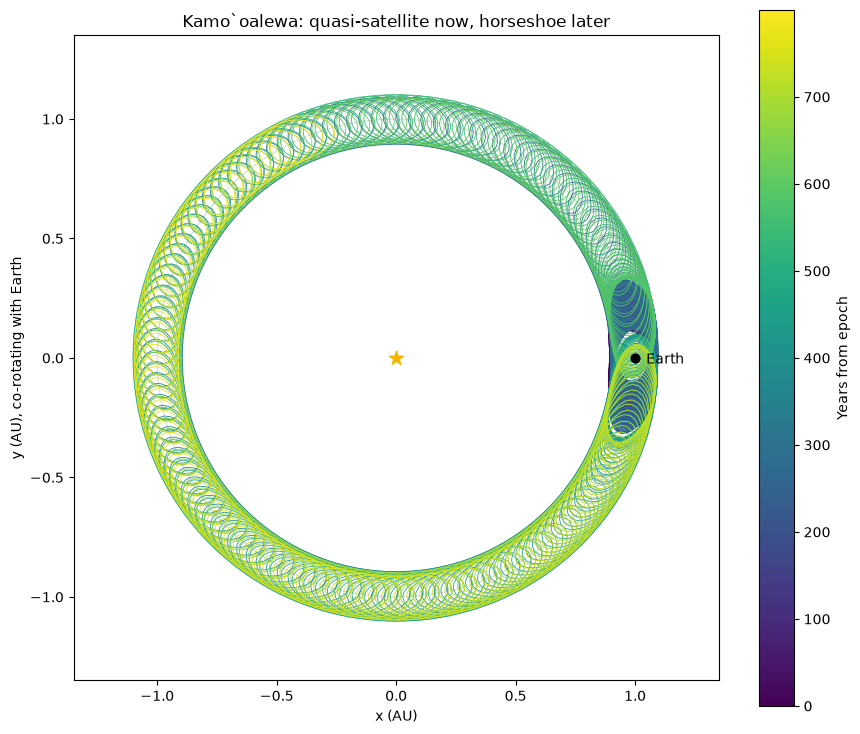

In [7]:
fig2, ax2 = plt.subplots(figsize=(9, 9))
pts = rot[:, 0, :].reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap="viridis", array=times_yr[:-1], linewidths=0.6)
ax2.add_collection(lc)
cb = fig2.colorbar(lc, ax=ax2, shrink=0.8, label="Years from epoch")
ax2.plot(np.cos(th), np.sin(th), color="0.85", lw=0.8, zorder=0)
ax2.scatter([1], [0], s=40, color="black", zorder=4)
ax2.annotate("Earth", (1, 0), textcoords="offset points", xytext=(8, -4), fontsize=10)
ax2.scatter([0], [0], marker="*", s=110, color="#f4b400", zorder=4)
ax2.set_aspect("equal")
ax2.set_xlim(-1.35, 1.35)
ax2.set_ylim(-1.35, 1.35)
ax2.set_xlabel("x (AU)")
ax2.set_ylabel("y (AU), co-rotating with Earth")
ax2.set_title("Kamo`oalewa: quasi-satellite now, horseshoe later")
fig2.tight_layout()
plt.show()


The colour gradient reveals a double life:

- **Early on (dark purple)**, Kamoʻoalewa traces the tight quasi-satellite loops near Earth that we saw in Step 5.
- **In mid-integration (green)**, it escapes into a **horseshoe** circulation that carries it most of the way around Earth's orbit.
- **Late in the run (yellow)**, it returns toward quasi-satellite behaviour.

Kamoʻoalewa switches between the quasi-satellite and horseshoe states on centennial timescales ([de la Fuente Marcos & de la Fuente Marcos 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.462.3441D)). Happily for mission planners, **Tianwen-2** will visit it during its current, well-behaved quasi-satellite phase.


# Step 7: The Co-orbital Diagnostic

The shapes in the rotating frame are beautiful, but dynamicists usually compress each of them into a single curve: the asteroid's **longitude relative to Earth** as a function of time. The three co-orbital classes are then immediately distinguishable by which reference lines their curves embrace.

Because the yearly eccentricity epicycle superimposes a fast wobble on the slow co-orbital drift, we smooth the angle with a 1-year averaging window. Averaging an angle near the ±180° wrap requires a little care: we average the *complex phase* exp(i·dlam) rather than the raw angle, and we break the plotted line wherever it wraps so matplotlib does not draw spurious vertical jumps.


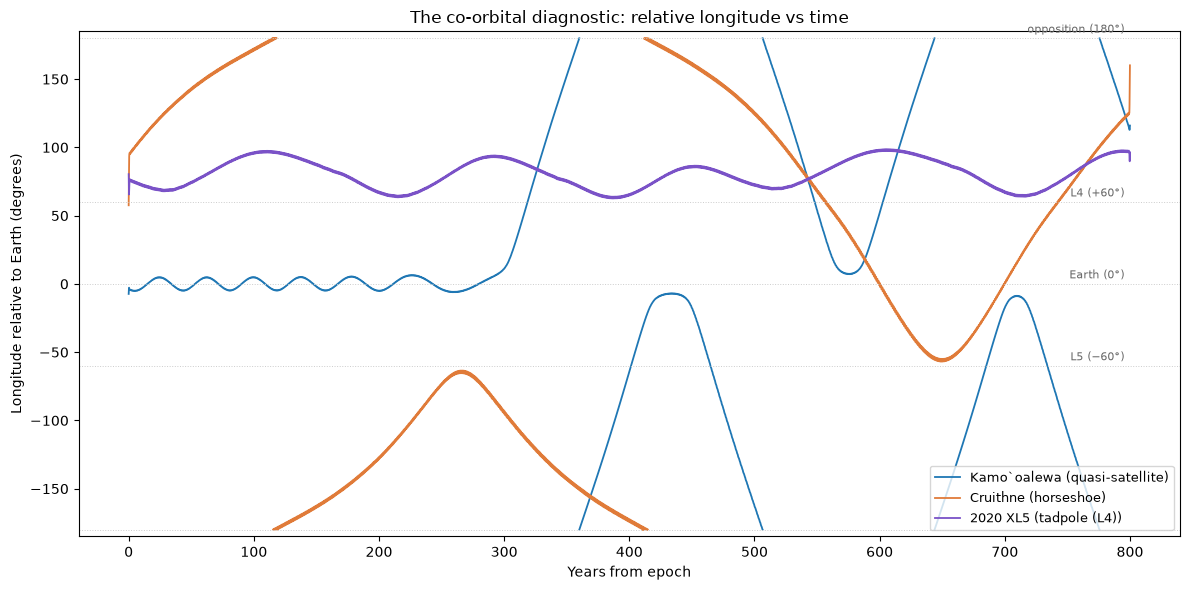

In [8]:
# Average the complex phase over a 1-year window to handle the +/-180 wrap
win = int(round(365.25 / dt_out))
kernel = np.ones(win) / win

fig3, ax3 = plt.subplots(figsize=(12, 6))
for j in range(3):
    phase = np.exp(1j * np.radians(dlam[:, j]))
    sm = np.convolve(phase, kernel, mode="same")
    dlam_sm = np.degrees(np.angle(sm))
    # break the line at +/-180 wraps so matplotlib does not draw jumps
    wrap = np.abs(np.diff(dlam_sm)) > 180
    dlam_plot = dlam_sm.copy()
    dlam_plot[1:][wrap] = np.nan
    ax3.plot(times_yr, dlam_plot, color=cols[j], lw=1.3,
             label=f"{names[j]} ({classes[j]})")

for yref, lab in [(0, "Earth (0°)"), (60, "L4 (+60°)"), (-60, "L5 (−60°)"),
                  (180, "opposition (180°)"), (-180, None)]:
    ax3.axhline(yref, color="0.8", lw=0.7, ls=":")
    if lab:
        ax3.annotate(lab, (times_yr[-1], yref), xytext=(-4, 4),
                     textcoords="offset points", ha="right", fontsize=8, color="0.4")

ax3.set_ylim(-185, 185)
ax3.set_xlabel("Years from epoch")
ax3.set_ylabel("Longitude relative to Earth (degrees)")
ax3.set_title("The co-orbital diagnostic: relative longitude vs time")
ax3.legend(loc="lower right", fontsize=9)
fig3.tight_layout()
plt.show()


How to read this plot:

- A **quasi-satellite** librates about **0°** — it stays alongside Earth.
- A **tadpole (Trojan)** librates about **+60° (L4)** or **-60° (L5)**.
- A **horseshoe** encloses **180°** (opposition) and always reverses direction before its curve can reach 0° — it never catches Earth up.

With that key, the three curves tell the whole story at a glance: 2020 XL5 (purple) oscillates gently around the L4 line; Cruithne (orange) sweeps across opposition with clear **turning points near years 265 and 650**; and Kamoʻoalewa (blue) hugs 0° as a quasi-satellite until, at **roughly year 300**, it breaks away into a horseshoe excursion before returning.


# A Caveat on Chaos

Co-orbital motion in the Earth-Moon neighbourhood is **chaotic**: tiny changes in the initial conditions grow exponentially. The *qualitative* behaviour shown here is robust — Kamoʻoalewa really does alternate between quasi-satellite and horseshoe states, Cruithne really is a horseshoe librator — but the *exact* transition times you obtain will differ between orbit solutions, between force models, and even between integrator settings. (Our model also ignores non-gravitational effects such as the Yarkovsky drift.)

For precision work you should integrate a cloud of orbital clones sampled from the orbit covariance matrix, and/or use an ephemeris-quality force model, rather than relying on a single trajectory.


# Going Further

Some ideas for extending this notebook:

- **Integrate backwards** in time to uncover Kamoʻoalewa's past quasi-satellite and horseshoe episodes.
- **Sample orbital clones** from the covariance matrix — as demonstrated in the [companion N-body tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/) — and watch chaotic divergence scramble the transition times.
- **Hunt for co-orbitals of Venus and Mars** in the MPC catalogue: both planets have their own quasi-satellites, Trojans and horseshoe companions.
- **Explore the temporarily-captured "mini-moons"**, such as 2024 PT5, which briefly become gravitationally bound to Earth before escaping.
- A tutorial on ephemeris-quality integrations with ASSIST is in preparation.


# Summary

In this tutorial we:

1. **Fetched** the orbits of three Earth co-orbitals — (469219) Kamoʻoalewa, (3753) Cruithne, and 2020 XL5 — from the MPC Orbits API
2. **Aligned** their Cartesian state vectors to a common epoch with a short two-body propagation
3. **Integrated** the system for 800 years with REBOUND's `ias15` integrator, alongside the Sun and all eight planets
4. **Transformed** the trajectories into the frame co-rotating with Earth, where co-orbital motion becomes visible
5. **Identified** the three co-orbital shapes: Kamoʻoalewa's retrograde quasi-satellite loops, Cruithne's horseshoe, and 2020 XL5's L4 tadpole
6. **Watched** Kamoʻoalewa switch from quasi-satellite to horseshoe and back on centennial timescales
7. **Compressed** all of that dynamics into a single relative-longitude diagnostic plot

### Further Resources

- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)
- [Companion N-body tutorial: From MPC Orbit to N-Body Simulation with Rebound](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)
- [REBOUND documentation](https://rebound.readthedocs.io/)
- [Quasi-satellite](https://en.wikipedia.org/wiki/Quasi-satellite) and [Horseshoe orbit](https://en.wikipedia.org/wiki/Horseshoe_orbit) (Wikipedia)
- [de la Fuente Marcos & de la Fuente Marcos 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.462.3441D) — Kamoʻoalewa dynamics
- [Castro-Cisneros et al. 2023](https://www.nature.com/articles/s43247-023-01031-w) — Kamoʻoalewa's possible lunar-ejecta origin
- [Wiegert, Innanen & Mikkola 1997](https://ui.adsabs.harvard.edu/abs/1997Natur.387..685W) — Cruithne's horseshoe orbit
- [Santana-Ros et al. 2022](https://ui.adsabs.harvard.edu/abs/2022NatCo..13..447S) — the discovery of 2020 XL5

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).
